<a href="https://colab.research.google.com/github/amriteshamr/AI-Threat-Detection/blob/main/main_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df1 = pd.read_csv("Friday-WorkingHours-Morning.pcap_ISCX.csv")
df2 = pd.read_csv("Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv")
df3 = pd.read_csv("Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
df4 = pd.read_csv("Monday-WorkingHours.pcap_ISCX.csv")
df5 = pd.read_csv("Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv")
df6 = pd.read_csv("Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv")
df7 = pd.read_csv("Tuesday-WorkingHours.pcap_ISCX.csv")
df8 = pd.read_csv("Wednesday-workingHours.pcap_ISCX.csv")

In [38]:
df = pd.concat([df1, df2, df3, df4, df5, df6, df7, df8])

In [4]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3268,112740690.0,32.0,16.0,6448.0,1152.0,403.0,0.0,201.5,204.724205,...,32.0,3.594286e+02,1.199802e+01,380.0,343.0,16100000.0,4.988048e+05,16400000.0,15400000.0,BENIGN
1,389,112740560.0,32.0,16.0,6448.0,5056.0,403.0,0.0,201.5,204.724205,...,32.0,3.202857e+02,1.574499e+01,330.0,285.0,16100000.0,4.987937e+05,16400000.0,15400000.0,BENIGN
2,0,113757377.0,545.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,9.361829e+06,7.324646e+06,18900000.0,19.0,12200000.0,6.935824e+06,20800000.0,5504997.0,BENIGN
3,5355,100126.0,22.0,0.0,616.0,0.0,28.0,28.0,28.0,0.000000,...,32.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0,BENIGN
4,0,54760.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0,BENIGN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2078121 entries, 0 to 384633
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                float64
 2    Total Fwd Packets            float64
 3    Total Backward Packets       float64
 4   Total Length of Fwd Packets   float64
 5    Total Length of Bwd Packets  float64
 6    Fwd Packet Length Max        float64
 7    Fwd Packet Length Min        float64
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         float64
 11   Bwd Packet Length Min        float64
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max               

In [39]:
df.isnull().sum()

,0
Destination Port,0
Flow Duration,1
Total Fwd Packets,1
Total Backward Packets,1
Total Length of Fwd Packets,1
...,...
Idle Mean,5
Idle Std,5
Idle Max,5
Idle Min,5


In [40]:
df.columns = df.columns.str.strip()

In [41]:
print(df['Label'].value_counts())

Label
BENIGN                        1719462
DoS Hulk                       231073
DDoS                            96847
FTP-Patator                      7938
SSH-Patator                      5829
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
DoS GoldenEye                    1118
Web Attack � XSS                  652
PortScan                          372
Infiltration                       36
Web Attack � Sql Injection         21
Name: count, dtype: int64


In [42]:
df = df.dropna()

In [44]:
df.shape

(2076813, 79)

In [45]:
import numpy as np
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

In [46]:
# Features
X = df.drop(columns=["Label"])

# Target
y = df["Label"]

In [49]:
print(y.value_counts())

Label
BENIGN                        1719108
DoS Hulk                       230124
DDoS                            96847
FTP-Patator                      7938
SSH-Patator                      5829
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
DoS GoldenEye                    1118
Web Attack � XSS                  652
PortScan                          372
Infiltration                       36
Web Attack � Sql Injection         21
Name: count, dtype: int64


In [50]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [51]:
print(y.map(type).value_counts())

Label
<class 'str'>    2076813
Name: count, dtype: int64


In [52]:
y = le.fit_transform(df["Label"])

In [53]:
display(X)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,3268,112740690.0,32.0,16.0,6448.0,1152.0,403.0,0.0,201.500000,204.724205,...,15.0,32.0,3.594286e+02,1.199802e+01,380.0,343.0,16100000.0,4.988048e+05,16400000.0,15400000.0
1,389,112740560.0,32.0,16.0,6448.0,5056.0,403.0,0.0,201.500000,204.724205,...,15.0,32.0,3.202857e+02,1.574499e+01,330.0,285.0,16100000.0,4.987937e+05,16400000.0,15400000.0
2,0,113757377.0,545.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,9.361829e+06,7.324646e+06,18900000.0,19.0,12200000.0,6.935824e+06,20800000.0,5504997.0
3,5355,100126.0,22.0,0.0,616.0,0.0,28.0,28.0,28.000000,0.000000,...,21.0,32.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0
4,0,54760.0,4.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384628,53,48460.0,4.0,2.0,100.0,114.0,25.0,25.0,25.000000,0.000000,...,3.0,20.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0
384629,138,27.0,13.0,0.0,3029.0,0.0,233.0,233.0,233.000000,0.000000,...,12.0,20.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0
384630,138,59.0,13.0,0.0,3029.0,0.0,233.0,233.0,233.000000,0.000000,...,12.0,20.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0
384631,53,93664403.0,3.0,3.0,158.0,319.0,61.0,41.0,52.666667,10.408330,...,2.0,20.0,6.046900e+04,0.000000e+00,60469.0,60469.0,93000000.0,0.000000e+00,93000000.0,93000000.0


In [54]:
display(y)

array([0, 0, 0, ..., 0, 0, 0])

In [55]:
print(dict(enumerate(le.classes_)))

{0: 'BENIGN', 1: 'Bot', 2: 'DDoS', 3: 'DoS GoldenEye', 4: 'DoS Hulk', 5: 'DoS Slowhttptest', 6: 'DoS slowloris', 7: 'FTP-Patator', 8: 'Infiltration', 9: 'PortScan', 10: 'SSH-Patator', 11: 'Web Attack � Brute Force', 12: 'Web Attack � Sql Injection', 13: 'Web Attack � XSS'}


In [57]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [58]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.08630099430671595), np.int64(1): np.float64(74.54459798994975), np.int64(2): np.float64(1.5322591057571884), np.int64(3): np.float64(132.44977678571428), np.int64(4): np.float64(0.644017300418401), np.int64(5): np.float64(27.25028702640643), np.int64(6): np.float64(25.620682210708118), np.int64(7): np.float64(18.571987480438185), np.int64(8): np.float64(3828.2258064516127), np.int64(9): np.float64(391.6666666666667), np.int64(10): np.float64(25.428540818512964), np.int64(11): np.float64(98.89583333333333), np.int64(12): np.float64(7911.666666666667), np.int64(13): np.float64(229.99031007751938)}


In [59]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [61]:
num_classes = len(np.unique(y_train))

print("Input features:", X_train.shape[1])
print("Number of classes:", num_classes)

Input features: 78
Number of classes: 14


In [62]:
model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(num_classes, activation="softmax")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [63]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        10,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 14)             │           910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,278 (75.30 KB)

 Trainable params: 19,278 (75.30 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam
opt = Adam(learning_rate=0.0001)

In [64]:
model.compile(loss='sparse_categorical_crossentropy', optimizer="adam", metrics=['accuracy'])

In [ ]:
pd.DataFrame(X_train).describe()

,0,1,2,3,4,5,6,7,8,9,...,68,69,70,71,72,73,74,75,76,77
count,1.662496e+06,1.662496e+06,1.662496e+06,1.662496e+06,1.662496e+06,1.662496e+06,1.662496e+06,1.662496e+06,1.662496e+06,1.662496e+06,...,1.662496e+06,1.662496e+06,1.662496e+06,1.662496e+06,1.662496e+06,1.662496e+06,1.662496e+06,1.662496e+06,1.662496e+06,1.662496e+06
mean,-2.345545e-17,1.894215e-17,1.880539e-19,-5.556137e-19,3.470449e-18,4.786826e-19,-1.193928e-17,1.202690e-17,-1.906781e-16,8.898153e-17,...,-2.094236e-18,1.128323e-18,4.417556e-17,-1.242010e-17,-2.333578e-17,9.086421e-18,-1.088490e-16,-3.143064e-17,1.632649e-17,-1.384760e-18
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-4.144540e-01,-4.939641e-01,-1.279490e-02,-1.083753e-02,-5.038094e-02,-7.892466e-03,-3.175817e-01,-3.087236e-01,-3.297790e-01,-2.736178e-01,...,-8.869281e-03,-3.824469e+02,-1.338580e-01,-1.120206e-01,-1.602150e-01,-1.070603e-01,-3.960629e-01,-1.188994e-01,-4.018956e-01,-3.822916e-01
25%,-4.114789e-01,-4.939584e-01,-1.058051e-02,-1.000831e-02,-4.942185e-02,-7.892466e-03,-3.094650e-01,-3.087236e-01,-2.983176e-01,-2.736178e-01,...,-8.869281e-03,3.065572e-03,-1.338580e-01,-1.120206e-01,-1.602150e-01,-1.070603e-01,-3.960629e-01,-1.188994e-01,-4.018956e-01,-3.822916e-01
50%,-4.099633e-01,-4.925650e-01,-1.058051e-02,-9.179085e-03,-4.510592e-02,-7.839340e-03,-2.621177e-01,-3.087236e-01,-1.357669e-01,-2.736178e-01,...,-7.603236e-03,3.065572e-03,-1.338580e-01,-1.120206e-01,-1.602150e-01,-1.070603e-01,-3.960629e-01,-1.188994e-01,-4.018956e-01,-3.822916e-01
75%,-3.895866e-01,-3.384615e-01,-6.151743e-03,-6.691413e-03,-2.232745e-02,-7.224338e-03,4.361055e-02,3.011697e-01,-5.186974e-02,1.787730e-02,...,-5.071144e-03,3.074121e-03,-1.338580e-01,-1.120206e-01,-1.602150e-01,-1.070603e-01,-3.960629e-01,-1.188994e-01,-4.018956e-01,-3.822916e-01
max,3.264241e+00,2.798963e+00,2.433026e+02,2.420578e+02,1.030975e+03,2.418068e+02,3.325842e+01,3.853809e+01,3.082153e+01,2.429705e+01,...,2.703641e+02,3.149632e-03,1.524478e+02,1.633689e+02,9.661319e+01,1.714165e+02,4.148257e+00,1.582876e+01,4.024994e+00,4.201952e+00


In [ ]:
print(np.unique(y))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


In [66]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/10
5193/5193 ━━━━━━━━━━━━━━━━━━━━ 35s 7ms/step - accuracy: 0.7277 - loss: 0.6495 - val_accuracy: 0.7765 - val_loss: 0.6538
Epoch 2/10
5193/5193 ━━━━━━━━━━━━━━━━━━━━ 35s 7ms/step - accuracy: 0.7407 - loss: 0.9596 - val_accuracy: 0.7642 - val_loss: 0.7284
Epoch 3/10
5193/5193 ━━━━━━━━━━━━━━━━━━━━ 35s 7ms/step - accuracy: 0.7367 - loss: 1.2287 - val_accuracy: 0.7676 - val_loss: 0.6687
Epoch 4/10
5193/5193 ━━━━━━━━━━━━━━━━━━━━ 35s 7ms/step - accuracy: 0.7397 - loss: 0.7766 - val_accuracy: 0.7642 - val_loss: 0.7416
Epoch 5/10
5193/5193 ━━━━━━━━━━━━━━━━━━━━ 35s 7ms/step - accuracy: 0.7352 - loss: 0.7438 - val_accuracy: 0.7742 - val_loss: 0.6727
Epoch 6/10
5193/5193 ━━━━━━━━━━━━━━━━━━━━ 42s 7ms/step - accuracy: 0.7419 - loss: 1.2179 - val_accuracy: 0.7643 - val_loss: 0.8186
Epoch 7/10
5193/5193 ━━━━━━━━━━━━━━━━━━━━ 37s 7ms/step - accuracy: 0.7486 - loss: 0.9462 - val_accuracy: 0.7858 - val_loss: 0.7002
Epoch 8/10
5193/5193 ━━━━━━━━━━━━━━━━━━━━ 38s 7ms/step - accuracy: 0.7517 - loss: 2

In [67]:
loss, accuracy = model.evaluate(X_test, y_test)
print('Test Loss:', loss)
print('Test Accuracy:', accuracy)

12981/12981 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step - accuracy: 0.7695 - loss: 0.8972
Test Loss: 0.8971574306488037
Test Accuracy: 0.7694907784461975


In [68]:
y_prob = model.predict(X_test)

y_pred = np.argmax(y_prob, axis=1)

12981/12981 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step


In [69]:
print(y_pred[:10])
print(y_test[:10])

[2 0 9 1 0 0 0 8 0 0]
[2 0 0 0 0 0 0 0 0 0]


In [71]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_,
        digits=4
    )
)

                            precision    recall  f1-score   support

                    BENIGN     0.9998    0.7261    0.8412    343979
                       Bot     0.0132    0.9492    0.0260       374
                      DDoS     0.8858    0.9805    0.9307     19396
             DoS GoldenEye     0.0655    0.9820    0.1228       222
                  DoS Hulk     0.7201    0.9838    0.8315     45851
          DoS Slowhttptest     0.3749    0.9781    0.5420      1144
             DoS slowloris     0.2426    0.9734    0.3883      1164
               FTP-Patator     0.1955    0.9942    0.3267      1548
              Infiltration     0.0015    1.0000    0.0030         5
                  PortScan     0.0046    0.8841    0.0091        69
               SSH-Patator     0.1467    0.9905    0.2555      1162
  Web Attack � Brute Force     0.0315    0.0782    0.0449       307
Web Attack � Sql Injection     0.0003    0.3333    0.0006         6
          Web Attack � XSS     0.0425    0.9779

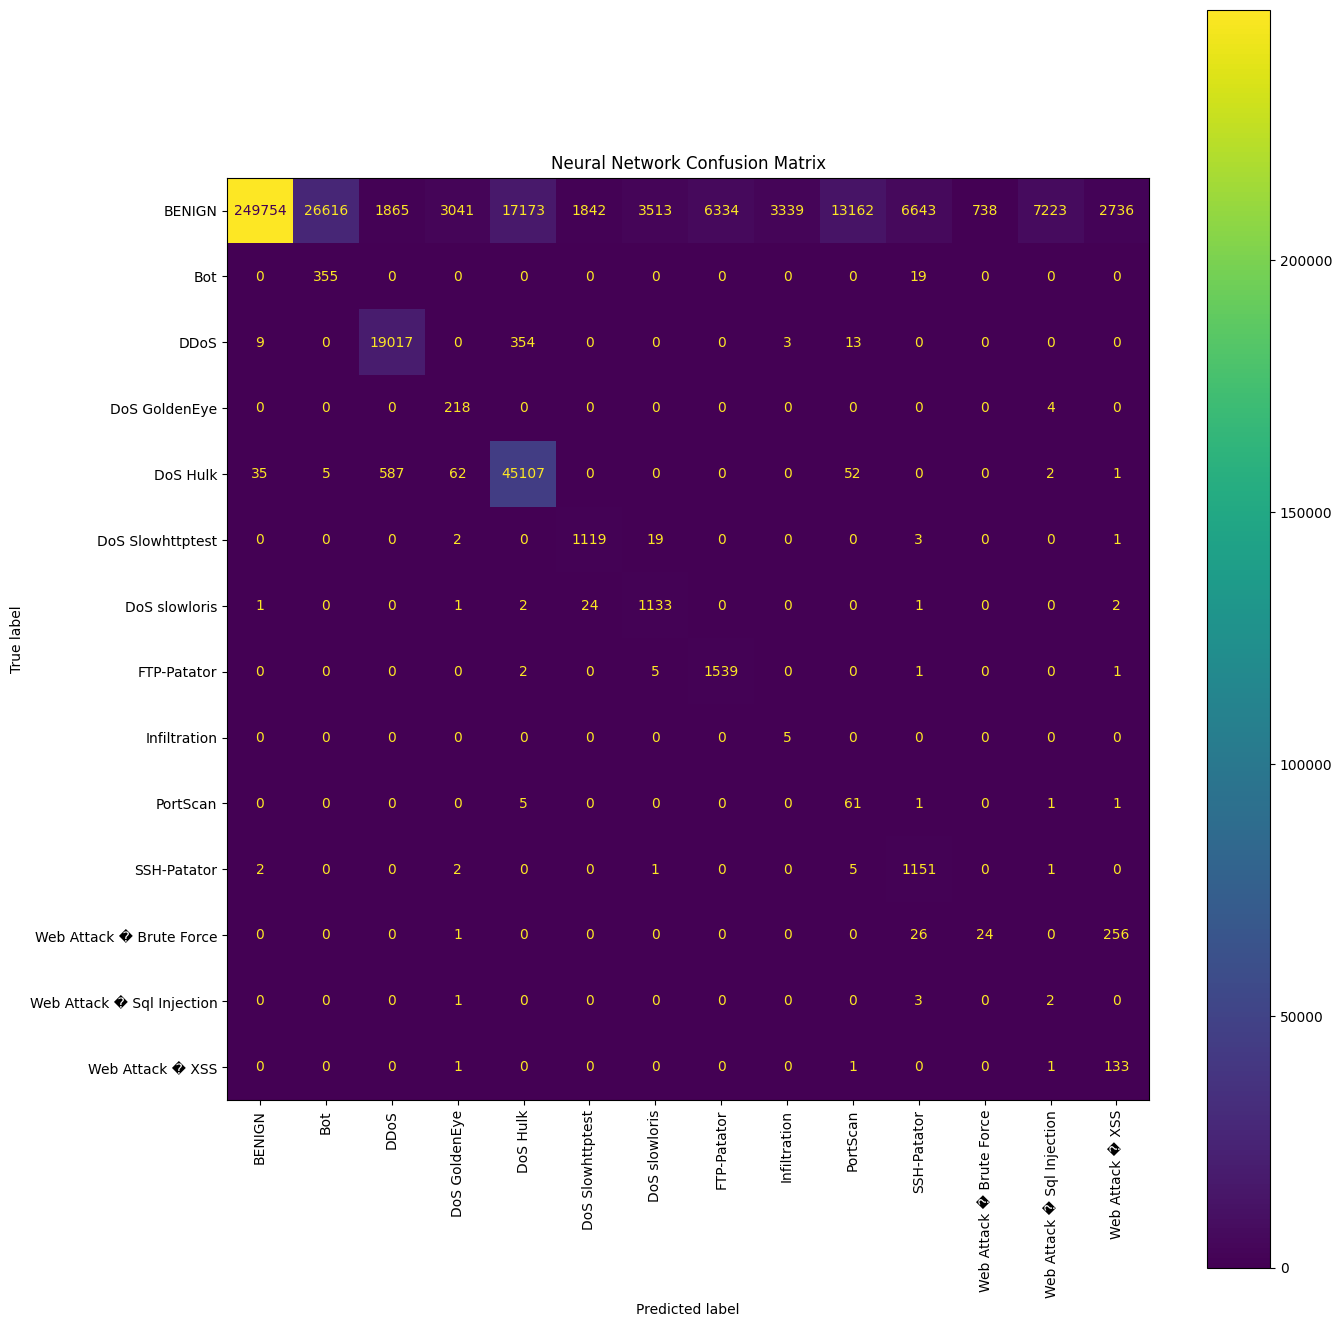

In [73]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(14, 14))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=le.classes_,
    xticks_rotation=90,
    ax=ax
)

plt.title("Neural Network Confusion Matrix")
plt.tight_layout()
plt.show()

In [74]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
5193/5193 ━━━━━━━━━━━━━━━━━━━━ 37s 7ms/step - accuracy: 0.9545 - loss: 0.1387 - val_accuracy: 0.9769 - val_loss: 0.0587
Epoch 2/20
5193/5193 ━━━━━━━━━━━━━━━━━━━━ 36s 7ms/step - accuracy: 0.9740 - loss: 0.0735 - val_accuracy: 0.9804 - val_loss: 0.0491
Epoch 3/20
5193/5193 ━━━━━━━━━━━━━━━━━━━━ 36s 7ms/step - accuracy: 0.9796 - loss: 0.0545 - val_accuracy: 0.9832 - val_loss: 0.0418
Epoch 4/20
5193/5193 ━━━━━━━━━━━━━━━━━━━━ 37s 7ms/step - accuracy: 0.9828 - loss: 0.0463 - val_accuracy: 0.9852 - val_loss: 0.0396
Epoch 5/20
5193/5193 ━━━━━━━━━━━━━━━━━━━━ 35s 7ms/step - accuracy: 0.9844 - loss: 0.0423 - val_accuracy: 0.9837 - val_loss: 0.0346
Epoch 6/20
5193/5193 ━━━━━━━━━━━━━━━━━━━━ 35s 7ms/step - accuracy: 0.9855 - loss: 0.0391 - val_accuracy: 0.9855 - val_loss: 0.0327
Epoch 7/20
5193/5193 ━━━━━━━━━━━━━━━━━━━━ 34s 6ms/step - accuracy: 0.9863 - loss: 0.0366 - val_accuracy: 0.9879 - val_loss: 0.0294
Epoch 8/20
5193/5193 ━━━━━━━━━━━━━━━━━━━━ 35s 7ms/step - accuracy: 0.9868 - loss: 0